# Diabetes XAI snapshot (Papermill)
Lightweight **RandomForest + SHAP** run on sklearn's `load_diabetes` — mirrors the tabular spirit of the main notebook without re-running the full Keras stack.

In [1]:
random_state = 42
max_samples = 400
model_n_estimators = 120

In [2]:
# Parameters
random_state = 42
max_samples = 400
model_n_estimators = 120


Holdout R^2: 0.4598


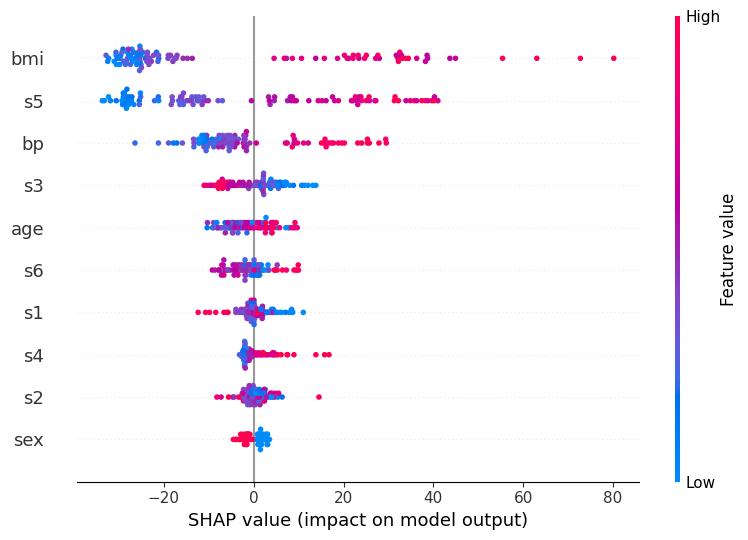

In [3]:
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X, y = load_diabetes(return_X_y=True)
feature_names = load_diabetes().feature_names
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=random_state
)
if max_samples:
    cap = min(len(X_train), int(max_samples))
    X_train = X_train[:cap]
    y_train = y_train[:cap]

model = RandomForestRegressor(
    n_estimators=int(model_n_estimators),
    random_state=random_state,
    n_jobs=-1,
)
model.fit(X_train, y_train)
score = model.score(X_test, y_test)
print(f"Holdout R^2: {score:.4f}")

explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(X_test[:100])
shap.summary_plot(shap_vals, X_test[:100], feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()